In [2]:
# Importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [21]:
df = pd.read_csv("Fraud.csv",low_memory=False)

In [ ]:
df

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
Dataset Knowledge

step - maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).

type - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.

amount - amount of the transaction in local currency.

nameOrig - customer who started the transaction

oldbalanceOrg - initial balance before the transaction

newbalanceOrig - new balance after the transaction

nameDest - customer who is the recipient of the transaction

oldbalanceDest - initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).

newbalanceDest - new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).

isFraud - This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.

isFlaggedFraud - The business model aims to control massive transfers from one account to another and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200.000 in a single transaction.


In [ ]:
# Basic Data Exploration

In [12]:
df.info

<bound method DataFrame.info of          step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        0   
1

In [6]:
df.columns


Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [7]:
df.shape

(6362620, 11)

In [10]:
df.size

69988820

In [11]:
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [12]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [13]:
df.describe(include=["object"])

,type,nameOrig,nameDest
count,6362620,6362620,6362620
unique,5,6353307,2722362
top,CASH_OUT,C1902386530,C1286084959
freq,2237500,3,113


In [13]:
df.describe(include="all")

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffDest
count,6.362620e+06,6362620,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
unique,NaN,5,NaN,6353307,NaN,NaN,2722362,NaN,NaN,NaN,NaN,NaN
top,NaN,CASH_OUT,NaN,C1902386530,NaN,NaN,C1286084959,NaN,NaN,NaN,NaN,NaN
freq,NaN,2237500,NaN,3,NaN,NaN,113,NaN,NaN,NaN,NaN,NaN
mean,2.433972e+02,NaN,1.798619e+05,NaN,8.338831e+05,8.551137e+05,NaN,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06,1.242947e+05
std,1.423320e+02,NaN,6.038582e+05,NaN,2.888243e+06,2.924049e+06,NaN,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03,8.129391e+05
min,1.000000e+00,NaN,0.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.306083e+07
25%,1.560000e+02,NaN,1.338957e+04,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,NaN,7.487194e+04,NaN,1.420800e+04,0.000000e+00,NaN,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00,0.000000e+00
75%,3.350000e+02,NaN,2.087215e+05,NaN,1.073152e+05,1.442584e+05,NaN,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00,1.491054e+05


In [15]:
print("Type :", df["type"].duplicated())
print("*****************************")

Type : 0          False
1           True
2          False
3          False
4           True
           ...  
6362615     True
6362616     True
6362617     True
6362618     True
6362619     True
Name: type, Length: 6362620, dtype: bool
*****************************


In [16]:
print("TYPE :") 
print(df["type"].value_counts())
print("*****************************")

print("STEP :")
print(df["step"].value_counts())
print("*****************************")

print("AMOUNT :")
print(df["amount"].value_counts())
print("*****************************")

print("PAYEE_NAME :")
print(df["nameOrig"].value_counts())
print("*****************************")

print("PAYEE_ACCOUNT_BEFORE_TRANSACTION :")
print(df["oldbalanceOrg"].value_counts())
print("*****************************")

print("RECEIVER'S_ACCOUNT_AFTER_TRANSACTION :")
print(df["newbalanceOrig"].value_counts())
print("*****************************")

print("RECEIVER'S_NAME :")
print(df["nameDest"].value_counts())
print("*****************************")

print(" :", df["oldbalanceDest"].value_counts())
print("*****************************")

print(" :", df["newbalanceDest"].value_counts())
print("*****************************")

print("FRAUDULENT:")
print(df["isFraud"].value_counts())
print("*****************************")

print("FLAGGED_FRAUD:")
print(df["isFlaggedFraud"].value_counts())
print("*****************************")

TYPE :
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64
*****************************
STEP :
step
19     51352
18     49579
187    49083
235    47491
307    46968
       ...  
432        4
706        4
693        4
112        2
662        2
Name: count, Length: 743, dtype: int64
*****************************
AMOUNT :
amount
10000000.00    3207
10000.00         88
5000.00          79
15000.00         68
500.00           65
               ... 
8513.48           1
189137.90         1
1615.78           1
128891.19         1
12257.89          1
Name: count, Length: 5316900, dtype: int64
*****************************
PAYEE_NAME :
nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
              ..
C98968405      1
C720209255     1
C1567523029    1
C644777639     1
C1280323807    1
Name: count, Length: 6353307, dtype: int64
*****************************
PAYEE_ACCOUNT_BEF

<Axes: xlabel='type', ylabel='count'>

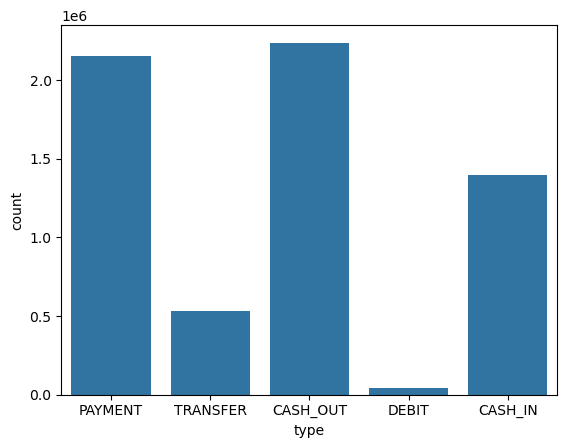

In [17]:
# Data Visualisation
sns.countplot(data=df, x='type')


<Axes: xlabel='step', ylabel='count'>

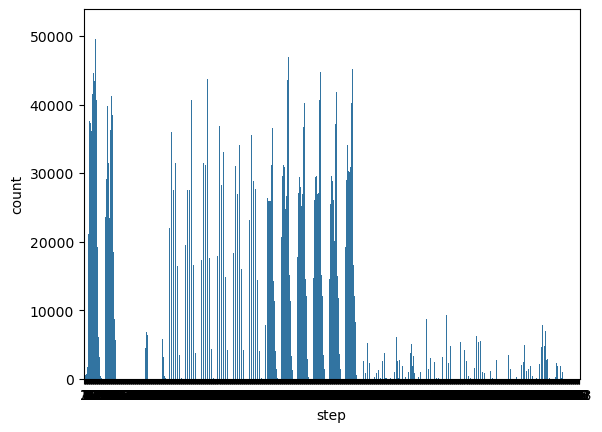

In [18]:
sns.countplot(data=df, x='step')

In [ ]:
# Data Preprocessing
# Data cleaning includes missing values,outliers and multi-collinearity

In [19]:
# Feature Engineering
df.isnull()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
6362615,False,False,False,False,False,False,False,False,False,False,False
6362616,False,False,False,False,False,False,False,False,False,False,False
6362617,False,False,False,False,False,False,False,False,False,False,False
6362618,False,False,False,False,False,False,False,False,False,False,False


In [14]:
df.isna().sum().sort_values(ascending = False)

step               0
type               0
amount             0
nameOrig           0
oldbalanceOrg      0
newbalanceOrig     0
nameDest           0
oldbalanceDest     0
newbalanceDest     0
isFraud            0
isFlaggedFraud     0
balanceDiffDest    0
dtype: int64

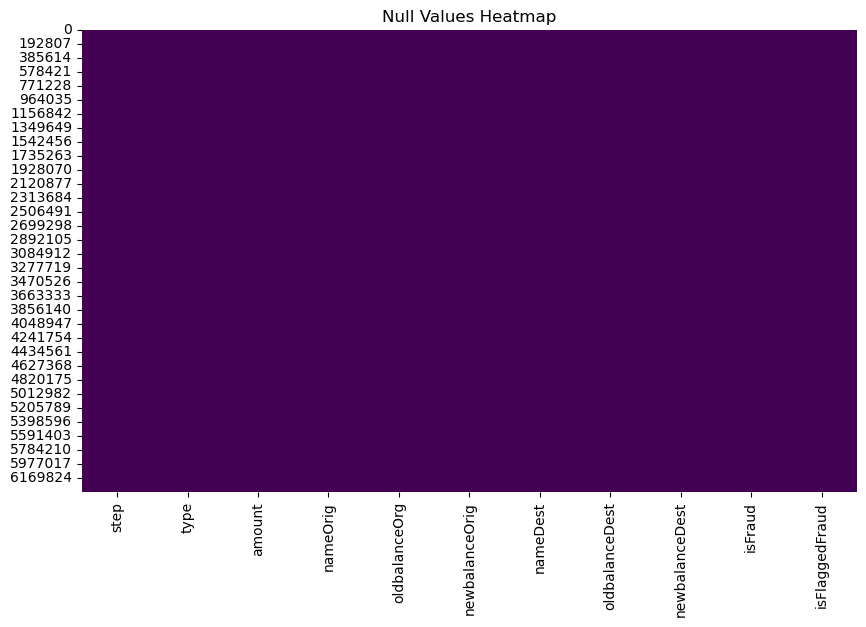

In [5]:

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cmap="viridis", cbar=False)
plt.title("Null Values Heatmap")
plt.show()

In [20]:
df.duplicated().value_counts()

False    6362620
Name: count, dtype: int64

In [15]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [34]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [12]:
df


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


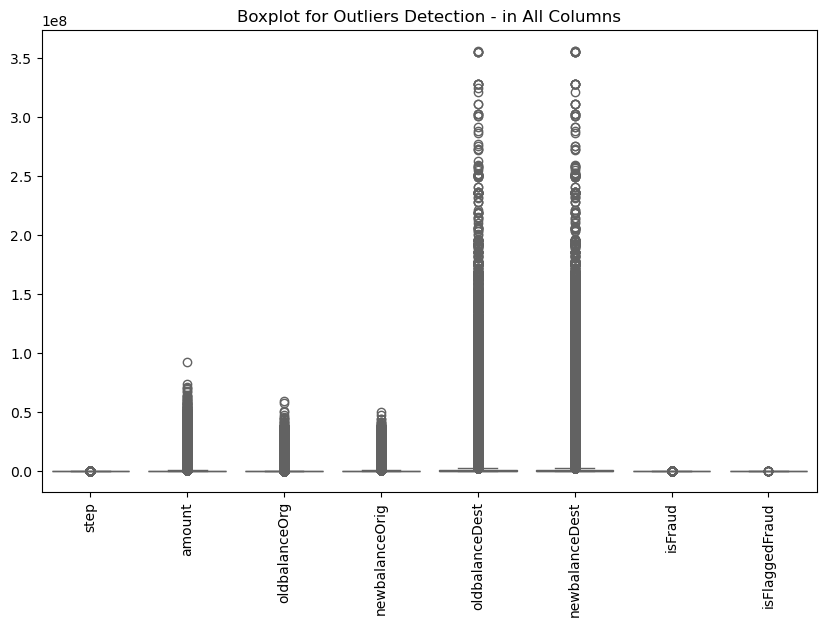

In [17]:
# Checking Outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, palette='Set3')
plt.title('Boxplot for Outliers Detection - in All Columns')
plt.xticks(rotation=90)
plt.show()

In [ ]:
There are too much outliers so we cannot impute them, we have to take outliers as our original data

In [18]:
df["balanceDiffDest"] = (df["newbalanceDest"]-df["oldbalanceDest"])

In [19]:
df["balanceDiffDest"] = (df["newbalanceDest"]-df["oldbalanceDest"])

In [23]:
#encoding  : Convert the categorical data to numerical data
				  #(i) dummy encoding/onehot encoding ---> it should be applied on nominal data
				  #(ii) ordinal encoding              ---> it should be applied on ordinal data
				  #(iii) label encoding		          ---> alphabetical order


from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()
df.type=label.fit_transform(df.type)
df.nameOrig=label.fit_transform(df.nameOrig)
df.nameDest=label.fit_transform(df.nameDest)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            int64  
 2   amount          float64
 3   nameOrig        int64  
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        int64  
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(6)
memory usage: 534.0 MB


In [6]:
df.head(1500)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,0.00
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,0.00
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,0.00
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,-21182.00
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1,CASH_OUT,29587.32,C987595204,31479.11,1891.79,C998351292,1751806.56,1015132.48,0,0,-736674.08
1496,1,PAYMENT,1056.64,C438123546,5578.00,4521.36,M29774113,0.00,0.00,0,0,0.00
1497,1,PAYMENT,2515.46,C22668134,270.00,0.00,M1474072872,0.00,0.00,0,0,0.00
1498,1,DEBIT,6077.94,C609389093,73904.00,67826.06,C775514090,11082.00,0.00,0,0,-11082.00


In [6]:
df.tail(3789)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6358831,715,PAYMENT,13834.99,C1182705486,10294.00,0.00,M1761467092,0.00,0.00,0,0
6358832,715,CASH_OUT,340063.82,C400064750,10244.00,0.00,C640758149,3360890.80,3700954.62,0,0
6358833,715,CASH_IN,153491.03,C974643500,6156.00,159647.03,C692500794,0.00,0.00,0,0
6358834,715,CASH_OUT,76027.53,C157312503,17039.00,0.00,C1757655028,56780.98,132808.50,0,0
6358835,715,CASH_IN,4738.35,C265102709,21368.00,26106.35,C760324867,3284696.27,3279957.93,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [25]:
corr_matrix = df.corr()
corr_matrix

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.000000,0.006635,0.022373,-0.000146,-0.010058,-0.010299,0.003767,0.027665,0.025888,0.031578,0.003277
type,0.006635,1.000000,0.088419,0.000213,-0.339760,-0.352758,0.584275,-0.104679,-0.059364,0.020833,0.002685
amount,0.022373,0.088419,1.000000,0.000124,-0.002762,-0.007861,-0.169150,0.294137,0.459304,0.076688,0.012295
nameOrig,-0.000146,0.000213,0.000124,1.000000,-0.000648,-0.000675,-0.000256,0.000245,0.000255,-0.000464,0.000667
oldbalanceOrg,-0.010058,-0.339760,-0.002762,-0.000648,1.000000,0.998803,-0.162688,0.066243,0.042029,0.010154,0.003835
newbalanceOrig,-0.010299,-0.352758,-0.007861,-0.000675,0.998803,1.000000,-0.166489,0.067812,0.041837,-0.008148,0.003776
nameDest,0.003767,0.584275,-0.169150,-0.000256,-0.162688,-0.166489,1.000000,-0.198119,-0.203992,-0.021963,-0.001122
oldbalanceDest,0.027665,-0.104679,0.294137,0.000245,0.066243,0.067812,-0.198119,1.000000,0.976569,-0.005885,-0.000513
newbalanceDest,0.025888,-0.059364,0.459304,0.000255,0.042029,0.041837,-0.203992,0.976569,1.000000,0.000535,-0.000529
isFraud,0.031578,0.020833,0.076688,-0.000464,0.010154,-0.008148,-0.021963,-0.005885,0.000535,1.000000,0.044109


In [26]:
corr_matrix["isFlaggedFraud"].sort_values(ascending=False)

isFlaggedFraud    1.000000
isFraud           0.044109
amount            0.012295
oldbalanceOrg     0.003835
newbalanceOrig    0.003776
step              0.003277
type              0.002685
nameOrig          0.000667
oldbalanceDest   -0.000513
newbalanceDest   -0.000529
nameDest         -0.001122
Name: isFlaggedFraud, dtype: float64

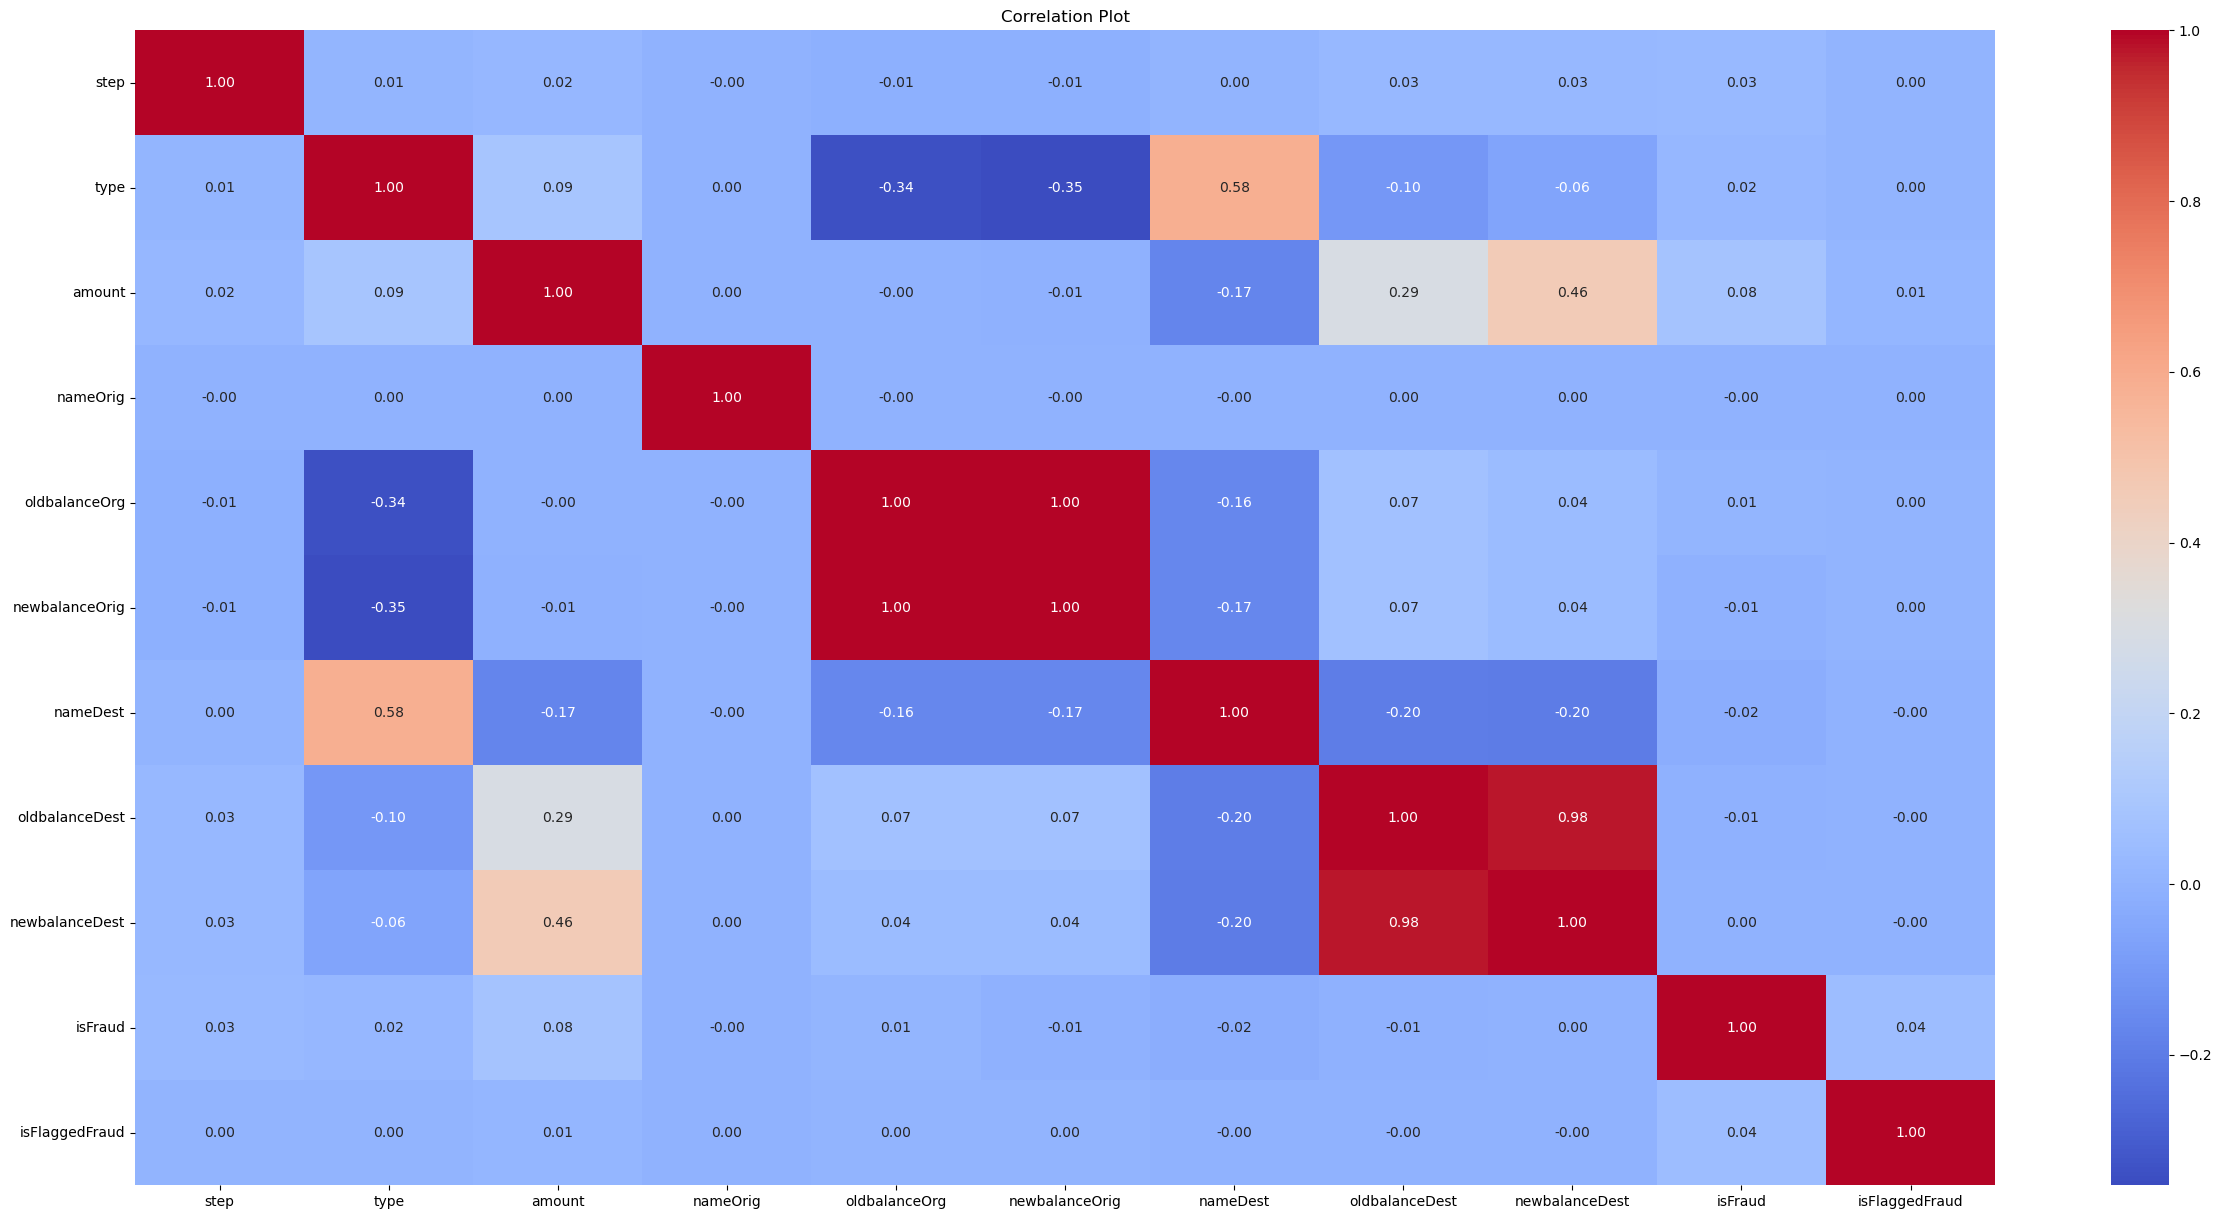

In [25]:
plt.figure(figsize=(30, 15))
sns.heatmap(df.corr(), annot=True, fmt= '.2f', cmap="coolwarm")
plt.title("Correlation Plot")
plt.show()

In [28]:
# One Hot Encoding
df = pd.get_dummies(df,columns=["type"], drop_first=True)



In [29]:
# Define features and target variable
X = df.drop(["nameOrig","nameDest", "isFlaggedFraud", "isFraud"], axis=1)
y = df["isFraud"]


In [30]:
X.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_1,type_2,type_3,type_4
0,1,9839.64,170136.0,160296.36,0.0,0.0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,False,False,True,False


In [31]:
X.tail()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_1,type_2,type_3,type_4
6362615,743,339682.13,339682.13,0.0,0.00,339682.13,True,False,False,False
6362616,743,6311409.28,6311409.28,0.0,0.00,0.00,False,False,False,True
6362617,743,6311409.28,6311409.28,0.0,68488.84,6379898.11,True,False,False,False
6362618,743,850002.52,850002.52,0.0,0.00,0.00,False,False,False,True
6362619,743,850002.52,850002.52,0.0,6510099.11,7360101.63,True,False,False,False


In [32]:
y.head()

0    0
1    0
2    1
3    1
4    0
Name: isFraud, dtype: int64

In [43]:
y.tail()

6362615    1
6362616    1
6362617    1
6362618    1
6362619    1
Name: isFraud, dtype: int64

In [33]:
# Train-Test Split
from sklearn.model_selection import train_test_split

# Splitting the data into test and train for calculating accuracy
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [34]:

X_train.shape

(5090096, 10)

In [35]:
X_test.shape

(1272524, 10)

In [36]:

y_train.shape

(5090096,)

In [37]:
y_test.shape

(1272524,)

In [38]:
# Model Training

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report




In [17]:

#modeling Decision tree

rf_model = RandomForestClassifier(n_estimators = 100, max_depth = 10, min_samples_split = 5, min_samples_leaf = 2,class_weight = 'balanced', random_state = 42, n_jobs =- 1)


In [18]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
# Predictions
y_pred = rf_model.predict(X_test)


In [20]:
y_prob = rf_model.predict_proba(X_test)[:,-1]

In [14]:
# Model Evaluation
print("\n========== MODEL PERFORMANCE ==========\n")


========== MODEL PERFORMANCE ==========



In [21]:
print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

Accuracy Score:
0.9857165758759756


In [16]:
print("Precision Score:")
print(precision_score(y_test, y_pred))

Precision Score:
0.07710889025718752


In [44]:
print("Recall Score:")
print(recall_score(y_test, y_pred))

Recall Score:
0.928180158247109


In [17]:
print("F1 Score:")
print(f1_score(y_test, y_pred))

F1 Score:
0.1430831429073651


In [18]:
print("ROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))

ROC-AUC Score:
0.9992488698166745


In [19]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.08      0.99      0.14      1643

    accuracy                           0.98   1272524
   macro avg       0.54      0.99      0.57   1272524
weighted avg       1.00      0.98      0.99   1272524



In [20]:
# Feature Importance
feature_importance = pd.DataFrame({'Feature': X.columns,'Importance': rf_model.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance',ascending=False)

In [21]:
print("Top Important Features:")
print(feature_importance.head(10))

Top Important Features:
          Feature  Importance
2   oldbalanceOrg    0.293020
3  newbalanceOrig    0.180400
1          amount    0.155549
9   type_TRANSFER    0.097711
6   type_CASH_OUT    0.065495
0            step    0.061704
8    type_PAYMENT    0.057018
5  newbalanceDest    0.047424
4  oldbalanceDest    0.041473
7      type_DEBIT    0.000206


In [23]:
# Hyperparameter Tuning: To improve model performance

from sklearn.model_selection import RandomizedSearchCV

param_grid = {'n_estimators':[50, 100, 150],'max_depth':[5, 10, 15, 20],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4],'max_features': ['sqrt', 'log2']}

# Base Model
rf = RandomForestClassifier(class_weight='balanced',random_state=42,n_jobs=-1)





In [24]:
# Randomized Search
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_grid, n_iter=5, cv=2, scoring='f1',verbose=2, random_state=42, n_jobs=-1)

In [25]:
# Fit Model
random_search.fit(X_train, y_train)

Fitting 2 folds for each of 5 candidates, totalling 10 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,5
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,2
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [26]:
# Best Parameters
print("Best Parameters:")
print(random_search.best_params_)



Best Parameters:
{'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}


In [27]:
# Best Score
print("\nBest F1 Score:")
print(random_search.best_score_)


Best F1 Score:
0.7938070810184282


In [33]:
# Predictions on Test Data
best_model = random_search.best_estimator_

In [34]:
y_pred = best_model.predict(X_test)

In [35]:
y_prob = best_model.predict_proba(X_test)[:, 1]



In [36]:
# Evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


In [37]:
print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))


Accuracy Score:
0.9989446171545684


In [38]:
print("\nPrecision Score:")
print(precision_score(y_test, y_pred))


Precision Score:
0.5545454545454546


In [39]:
print("\nRecall Score:")
print(recall_score(y_test, y_pred))


Recall Score:
0.928180158247109


In [40]:
print("\nF1 Score:")
print(f1_score(y_test, y_pred))


F1 Score:
0.6942863646710676


In [41]:
print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))


ROC-AUC Score:
0.998602517160683


In [42]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.55      0.93      0.69      1643

    accuracy                           1.00   1272524
   macro avg       0.78      0.96      0.85   1272524
weighted avg       1.00      1.00      1.00   1272524



In [43]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[1269656    1225]
 [    118    1525]]
